In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)

In [9]:
# ΚΕΛΙ 2
folder_path = "data"
# Διαβάζει τον φάκελο data και φτιάχνει
# μια λίστα με τα ονόματα όλων των αρχείων που τελειώνουν σε .csv.
files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

df_list = []

#Λούπα που μπαίνει σε κάθε αρχείο ξεχωριστά,
#το διαβάζει ως αυτόνομο DataFrame (pd.read_csv) και το αποθηκεύει προσωρινά στη λίστα df_list.
for file in files:
    temp_df = pd.read_csv(os.path.join(folder_path, file))
    df_list.append(temp_df)

#Το πιο σημαντικό βήμα. Παίρνει όλα τα ξεχωριστά DataFrames από τη λίστα
#και τα «κολλάει» το ένα κάτω από το άλλο (κάθετα), δημιουργώντας ένα τεράστιο, ενιαίο DataFrame df.
#Το ignore_index=True επαναφέρει την αρίθμηση των γραμμών από το 0 έως το σύνολο όλων των γραμμών,
#ώστε να μην υπάρχουν διπλοί δείκτες (indexes).
df = pd.concat(df_list, ignore_index=True)

#Αφαιρεί τυχόν κρυφούς αρχικούς ή τελικούς κενούς χώρους (spaces) από τα ονόματα των στηλών.
df.columns = df.columns.str.strip()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [10]:
# ΚΕΛΙ 3 
# Έλεγχος για Missing Values και Duplicates
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())



Total Missing Values:
1358

Duplicate Rows:
308381


In [11]:
# ΚΕΛΙ 4
# Remove duplicates
df.drop_duplicates(inplace=True)

# Replace inf values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove missing values
df.dropna(inplace=True)

print("Final Shape After Cleaning:", df.shape)

Final Shape After Cleaning: (2520798, 79)


In [12]:
# ΚΕΛΙ 5

# 1. Εντοπισμός Highly Correlated Features
# Υπολογισμός correlation matrix μόνο για numerical features
corr_matrix = df.select_dtypes(include=np.number).corr().abs()

# Δημιουργία upper triangle matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Εντοπισμός highly correlated features
high_corr_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

print(f"Highly correlated features ({len(high_corr_features)}):")
print(high_corr_features)

# 2. Εντοπισμός Low Variance Features
# Δημιουργία προσωρινού dataframe χωρίς το Label
X_temp = df.drop(columns=['Label'])

# Variance Threshold
selector = VarianceThreshold(threshold=0.01)

selector.fit(X_temp)

# Features με πολύ χαμηλή διακύμανση
low_variance_features = X_temp.columns[~selector.get_support()].tolist()

print(f"\nLow variance features ({len(low_variance_features)}):")
print(low_variance_features)

# 3. Δημιουργία τελικής λίστας features προς αφαίρεση
features_to_drop = list(
    set(high_corr_features + low_variance_features)
)

print(f"\nΣυνολικά features προς αφαίρεση: {len(features_to_drop)}")


# 4. Τελικό Feature Selection
df_reduced = df.drop(columns=features_to_drop)

print("\nΝέο σχήμα dataset μετά το feature selection:")
print(df_reduced.shape)

Highly correlated features (23):
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']

Low variance features (12):
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Συνολικά features προς αφαίρεση: 33

Νέο σχήμα dataset μετά το feature selection:
(2520798, 46)


In [13]:
# ΚΕΛΙ 6
# Διαχωρισμός χαρακτηριστικών (X) και πραγματικών labels (y)

# Το Label ΔΕΝ θα χρησιμοποιηθεί στην εκπαίδευση των clustering αλγορίθμων.
# Θα χρησιμοποιηθεί μόνο εκ των υστέρων για αξιολόγηση και ερμηνεία των clusters.

X = df_reduced.drop(columns=['Label'])
y = df_reduced['Label']

# Εκτύπωση σχημάτων
print("Features Shape (X):", X.shape)
print("Labels Shape (y):", y.shape)

Features Shape (X): (2520798, 45)
Labels Shape (y): (2520798,)


In [14]:
# ΚΕΛΙ 7
# Κωδικοποίηση των πραγματικών labels για πιθανή αξιολόγηση των clusters

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Αριθμός κλάσεων:", len(label_encoder.classes_))

Αριθμός κλάσεων: 15


In [15]:
# ΚΕΛΙ 8
# Εφαρμογή του φίλτρου Τυποποίησης (StandardScaler) σε όλο το σύνολο χαρακτηριστικών X
scaler_clustering = StandardScaler()

# Μετασχηματισμός των δεδομένων ώστε να αποκτήσουν Μέσο Όρο = 0 και Τυπική Απόκλιση = 1
X_scaled = scaler_clustering.fit_transform(X)

print("Το φίλτρο τυποποίησης εφαρμόστηκε με επιτυχία!")
print("Σχήμα τελικού πίνακα X_scaled:", X_scaled.shape)

Το φίλτρο τυποποίησης εφαρμόστηκε με επιτυχία!
Σχήμα τελικού πίνακα X_scaled: (2520798, 45)


# Επιλογή και Εφαρμογή Φίλτρου Κλίμακας

Για την κατάλληλη προεπεξεργασία των δεδομένων επιλέχθηκε και εφαρμόστηκε το φίλτρο `StandardScaler`. Η επιλογή ενός ενιαίου φίλτρου για όλους τους αλγορίθμους βασίζεται σε συγκεκριμένα στατιστικά και μαθηματικά κριτήρια που ικανοποιούν τις απαιτήσεις κάθε μεθόδου ξεχωριστά, χωρίς να χρειάζεται διαφορετική επεξεργασία για τον καθέναν. Συγκεκριμένα επιλέχθηκε γιατί:

1. **Ανθεκτικότητα σε Ακραίες Τιμές (Outliers):** Τα δεδομένα δικτυακής κυκλοφορίας περιέχουν έντονα spikes λόγω των επιθέσεων (π.χ. DoS/DDoS). Αν χρησιμοποιούσαμε κάποιον άλλον όπως τον `MinMaxScaler` (που συμπιέζει τα δεδομένα στο [0, 1]), αυτές οι ελάχιστες ακραίες τιμές θα έπαιρναν την τιμή 1, και το 99% των υπόλοιπων φυσιολογικών δεδομένων θα συμπιεζόταν τόσο κοντά στο 0 που οι αλγόριθμοι δεν θα μπορούσαν να διακρύνουν καμία δομή. Ο `StandardScaler` δεν έχει σταθερά όρια και διατηρεί τη στατιστική απόσταση των outliers χωρίς να καταστρέφει τη διασπορά των κανονικών δεδομένων.
2. **Μαθηματική Αναγκαιότητα για PCA:** Η εργασία ζητά στη συνέχεια τη χρήση της μεθόδου PCA για μείωση διαστάσεων. Η PCA βασίζεται στην ανάλυση της διακύμανσης (variance) και απαιτεί αυστηρά τα δεδομένα να έχουν μηδενικό μέσο όρο και μοναδιαία τυπική απόκλιση, ιδιότητα που προσφέρει αποκλειστικά ο `StandardScaler`.
3. **K-Means:** Ο αλγόριθμος υπολογίζει ευκλείδιες αποστάσεις προς τα κέντρα των clusters. Αν δεν εφαρμοζόταν ο `StandardScaler`, χαρακτηριστικά με τεράστιες αριθμητικές τιμές (π.χ. η διάρκεια ροής σε milliseconds) θα κυριαρχούσαν απόλυτα, εκμηδενίζοντας τη σημασία κρίσιμων χαρακτηριστικών με μικρές τιμές (π.χ. flag counts). Το φίλτρο δίνει σε όλα τα χαρακτηριστικά ίση βαρύτητα.
4. **DBSCAN:** Ο DBSCAN αναζητά πυκνότητες σημείων εντός μιας συγκεκριμένης γεωμετρικής ακτίνας (eps). Με την τυποποίηση, η ακτίνα eps αποκτά την ίδια στατιστική έννοια και μέτρο σε όλους τους άξονες του πολυδιάστατου χώρου, επιτρέποντας τον σωστό εντοπισμό πυκνών ομάδων επιθέσεων.
5. **Hierarchical Clustering:** Κατά τη σταδιακή δημιουργία του tree diagram, οι ενώσεις των σημείων βασίζονται στις αποστάσεις τους. Η τυποποίηση διασφαλίζει ότι οι ομάδες θα σχηματιστούν με βάση την πραγματική στατιστική συσχέτιση των δικτυακών χαρακτηριστικών και όχι λόγω τεχνητών διαφορών στην κλίμακα μέτρησής τους.

In [ ]:
# ΚΕΛΙ 9
# Δημιουργία αντιπροσωπευτικού δείγματος 10.000 εγγραφών με διατήρηση των αναλογιών (stratify)
# Διαχωρίζουμε τα τυποποιημένα δεδομένα (X_scaled) και τα κωδικοποιημένα labels (y_encoded)

_, X_sample, _, y_sample = train_test_split(
    X_scaled, 
    y_encoded, 
    test_size=10000,          # Μέγεθος δείγματος: 10.000 γραμμές για απόλυτη ασφάλεια στη RAM
    stratify=y_encoded,       # Διασφάλιση ότι δεν θα χαθούν οι σπάνιες κλάσεις επιθέσεων
    random_state=42           # Κλειδώνουμε την τυχαιότητα για σταθερά αποτελέσματα
)

print("Η δειγματοληψία ολοκληρώθηκε με επιτυχία!")
print("Σχήμα πίνακα χαρακτηριστικών δείγματος (X_sample):", X_sample.shape)
print("Σχήμα πίνακα labels δείγματος (y_sample):", y_sample.shape)

Η δειγματοληψία ολοκληρώθηκε με επιτυχία!
Σχήμα πίνακα χαρακτηριστικών δείγματος (X_sample): (10000, 45)
Σχήμα πίνακα labels δείγματος (y_sample): (10000,)


# Στρατηγική Δειγματοληψίας (Sampling) για τη Διαχείριση Υπολογιστικού Κόστους

Το καθαρισμένο dataset αποτελείται από 2.520.798 εγγραφές. Ενώ ο αλγόριθμος K-Means μπορεί να επεξεργαστεί αυτόν τον όγκο, αλγόριθμοι όπως ο DBSCAN και κυρίως ο Hierarchical Clustering απαιτούν τον υπολογισμό πινάκων αποστάσεων με υπολογιστική πολυπλοκότητα O(N^2), γεγονός που θα οδηγούσε σε άμεση εξάντληση της μνήμης RAM.
Ακόμη και να επεξεργαζόταν ο αλγόριθμος K-Means όλο τον όγκο των δεδομένων αυτό θα είχε ως αποτέλεσμα μεγάλο υπολογιστικό κόστος και δεν θα αποτελούσε κατάλληλο τρόπο σύγκρισης καθώς οι άλλοι αλγόριθμοι θα επεξεργαζόντουσαν πολύ μικρότερο όγκο δεδομένων.
Για την επίλυση αυτού του προβλήματος, επιλέχθηκε η εξαγωγή ενός αντιπροσωπευτικού δείγματος 10.000 εγγραφών μέσω της τεχνικής Στρωματοποιημένης Δειγματοληψίας (Stratified Sampling). 

Η χρήση της παραμέτρου `stratify` κρίνεται απολύτως κρίσιμη, καθώς διασφαλίζει ότι το δείγμα διατηρεί τις ακριβείς ποσοστιαίες αναλογίες των 15 κλάσεων (φυσιολογική κυκλοφορία και είδη επιθέσεων) του αρχικού πληθυσμού. Με αυτόν τον τρόπο:
1. Αποτρέπεται η πλήρης εξαφάνιση των σπάνιων (μειονοτικών) επιθέσεων από το δείγμα.
2. Διασφαλίζεται μια στατιστικά δίκαιη και έγκυρη σύγκριση, καθώς και οι τρεις αλγόριθμοι ομαδοποίησης θα αξιολογηθούν πάνω στα ίδια ακριβώς δεδομένα.
3. Αποφεύγονται προβλήματα εξάντλησης μνήμης.

In [18]:
# ΚΕΛΙ 10

# Αρχικοποίηση του PCA με στόχο τη διατήρηση του 95% της συνολικής πληροφορίας (variance)
pca = PCA(n_components=0.95, random_state=42)

# Εκπαίδευση του PCA και μετασχηματισμός του δείγματος X_sample
X_pca = pca.fit_transform(X_sample)

print("Η μείωση διαστάσεων με PCA ολοκληρώθηκε!")
print(f"Αρχικές διαστάσεις δείγματος: {X_sample.shape[1]}")
print(f"Νέες διαστάσεις μετά το PCA (95% πληροφορίας): {X_pca.shape[1]}")
print(f"Συνολικό ποσοστό πληροφορίας που διατηρήθηκε: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Η μείωση διαστάσεων με PCA ολοκληρώθηκε!
Αρχικές διαστάσεις δείγματος: 45
Νέες διαστάσεις μετά το PCA (95% πληροφορίας): 21
Συνολικό ποσοστό πληροφορίας που διατηρήθηκε: 95.83%


# Μείωση Διαστασιμότητας μέσω PCA

Μετά τη δειγματοληψία, εφαρμόστηκε η μέθοδος της **Ανάλυσης Κύριων Συνιστωσών (PCA)** στο τυποποιημένο δείγμα των 10.000 εγγραφών με στόχο τη μείωση του χώρου των χαρακτηριστικών.

# Ανάλυση Αποτελεσμάτων:
* Αρχικές Διαστάσεις: 45 χαρακτηριστικά.
* Νέες Διαστάσεις (Κύριες Συνιστώσες): 21 χαρακτηριστικά.
* Ποσοστό Πληροφορίας που Διατηρήθηκε: 95.83%.

# Συμπεράσματα Μεθοδολογίας:
Ορίζοντας την παράμετρο `n_components=0.95`, ο αλγόριθμος επέλεξε αυτόματα τον ελάχιστο αριθμό νέων, γραμμικά ασυσχέτιστων αξόνων που απαιτούνται για να μην χαθεί η πληροφορία του dataset. 

Το αποτέλεσμα κρίνεται επιτυχημένο, καθώς καταφέραμε να μειώσουμε τον όγκο των στηλών κατά περισσότερο από 50% (από 45 σε 21), διασφαλίζοντας παράλληλα ότι το 95.83% της συνολικής διακύμανσης (πληροφορίας) παραμένει άθικτο. Αυτή η συμπίεση μειώνει δραστικά τον υπολογιστικό χρόνο των αλγορίθμων συστοιχιοποίησης και απομονώνει τον στατιστικό θόρυβο, προετοιμάζοντας ιδανικά τα δεδομένα (`X_pca`) για την ομαδοποίηση που ακολουθεί.

Έναρξη Elbow Method για τον K-Means...


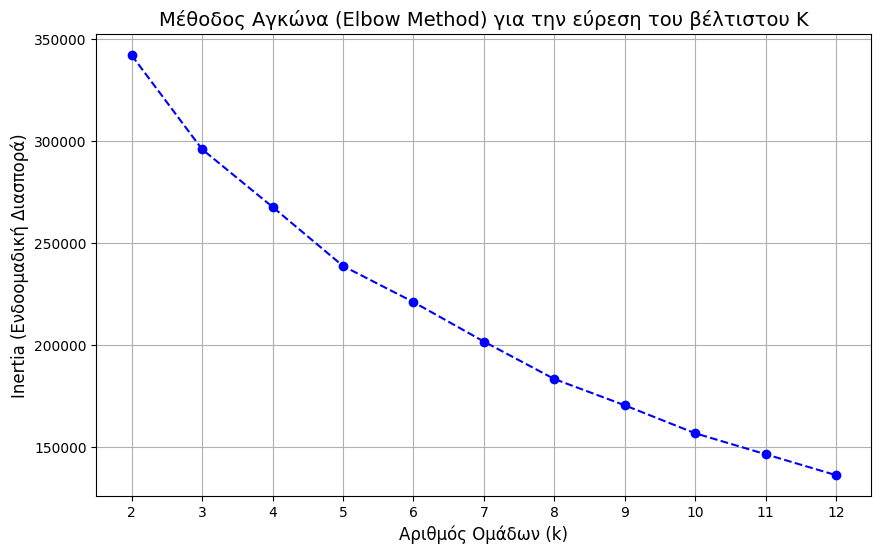

In [19]:
# ΚΕΛΙ 11

# Λίστα για την αποθήκευση των τιμών Inertia (αδράνειας) για κάθε k
inertia_values = []
k_range = range(2, 13) # Δοκιμάζουμε από 2 έως 12 clusters

print("Έναρξη Elbow Method για τον K-Means...")
for k in k_range:
    # Αρχικοποίηση και εκπαίδευση του K-Means στο πίνακα X_pca
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia_values.append(kmeans.inertia_)

# Σχεδίαση του γραφήματος Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='--', color='b')
plt.title('Μέθοδος Αγκώνα (Elbow Method) για την εύρεση του βέλτιστου K', fontsize=14)
plt.xlabel('Αριθμός Ομάδων (k)', fontsize=12)
plt.ylabel('Inertia (Ενδοομαδική Διασπορά)', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Ανάλυση Elbow Method για τον K-Means

Βάσει του γραφήματος της ενδοομαδικής διασποράς (Inertia) σε σχέση με τον αριθμό των ομάδων (k), παρατηρείται μια ομαλή, φθίνουσα καμπύλη, η οποία είναι τυπική σε σύνθετα δεδομένα κυβερνοασφάλειας όπου οι διάφορες κλάσεις επιθέσεων παρουσιάζουν επικαλύψεις στα χαρακτηριστικά τους.

# Κριτήριο Επιλογής Βέλτιστου K:
**Σημείο Καμπής:** Η εντονότερη αλλαγή στον ρυθμό μείωσης της Inertia εντοπίζεται στην τιμή k = 5. 
**Αιτιολόγηση:** Μέχρι το k = 5, η Inertia μειώνεται με γρήγορο ρυθμό, γεγονός που σημαίνει ότι η προσθήκη νέων κέντρων βελτιώνει σημαντικά τη συνοχή των ομάδων. Από το k = 6 και μετά, η καμπύλη σταθεροποιείται σε μια σχεδόν γραμμική πτώση. Αυτό υποδεικνύει ότι η περαιτέρω αύξηση των ομάδων θα οδηγούσε σε τεχνητή κατάτμηση (over-splitting) των ήδη υπαρχουσών δομών, χωρίς να προσφέρει ουσιαστική πληροφορία.

Ως αποτέλεσμα, η τιμή k = 5 επιλέγεται ως η χρυσή τομή (βέλτιστος αριθμός ομάδων) για την τελική εκπαίδευση του αλγορίθμου.

In [20]:
# ΚΕΛΙ 12
# 1. Αρχικοποίηση και εκπαίδευση του τελικού K-Means με k=5
optimal_k = 5
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Προβλέπουμε τα cluster labels για το δείγμα μας
kmeans_labels = final_kmeans.fit_transform(X_pca) # fit και εύρεση αποστάσεων
kmeans_preds = final_kmeans.labels_

# 2. Υπολογισμός των επίσημων μετρικών αξιολόγησης
print("Υπολογισμός μετρικών αξιολόγησης (παρακαλώ περιμένετε)...")

sh_score = silhouette_score(X_pca, kmeans_preds, random_state=42)
db_score = davies_bouldin_score(X_pca, kmeans_preds)

print("\n=== Αποτελέσματα Αξιολόγησης K-Means (k=5) ===")
print(f"Δείκτης Silhouette (Σιλουέτα): {sh_score:.4f}  (Ιδανικό: Κοντά στο +1)")
print(f"Δείκτης Davies-Bouldin:         {db_score:.4f}  (Ιδανικό: Κοντά στο 0)")

Υπολογισμός μετρικών αξιολόγησης (παρακαλώ περιμένετε)...

=== Αποτελέσματα Αξιολόγησης K-Means (k=5) ===
Δείκτης Silhouette (Σιλουέτα): 0.3194  (Ιδανικό: Κοντά στο +1)
Δείκτης Davies-Bouldin:         1.1918  (Ιδανικό: Κοντά στο 0)


Οι δείκτες αξιολόγησης για k=5 παρουσίασαν τις παραπάνω τιμές.
Τα αποτελέσματα αυτά θεωρούνται αναμενόμενα, καθώς το CIC-IDS-2017 είναι σύνθετο dataset με overlap μεταξύ benign και malicious traffic, θόρυβο και ανισορροπία κλάσεων. Επομένως δεν αναμένονται πλήρως διαχωρίσιμα clusters.
Το k=5 θεωρήθηκε η καταλληλότερη επιλογή, καθώς προσφέρει καλύτερη ισορροπία μεταξύ ποιότητας clustering και ερμηνευσιμότητας των ομάδων.

In [21]:
# ΚΕΛΙ 13

# Αρχικοποίηση και εκπαίδευση του DBSCAN στα δεδομένα του PCA
# eps: η ακτίνα γειτονιάς, min_samples: ελάχιστα δείγματα για δημιουργία πυρήνα
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_preds = dbscan.fit_predict(X_pca)

# Ο DBSCAN ονομάζει το θόρυβο με την τιμή -1. 
# Βρίσκουμε πόσα clusters εντόπισε (εξαιρώντας το -1)
n_clusters_dbscan = len(set(dbscan_preds)) - (1 if -1 in dbscan_preds else 0)
n_noise_dbscan = list(dbscan_preds).count(-1)

print("=== Αποτελέσματα DBSCAN ===")
print(f"Αριθμός ομάδων που εντοπίστηκαν: {n_clusters_dbscan}")
print(f"Αριθμός σημείων που θεωρήθηκαν θόρυβος (Anomalies): {n_noise_dbscan} (ποσοστό: {n_noise_dbscan/len(X_pca)*100:.2f}%)")

=== Αποτελέσματα DBSCAN ===
Αριθμός ομάδων που εντοπίστηκαν: 66
Αριθμός σημείων που θεωρήθηκαν θόρυβος (Anomalies): 2443 (ποσοστό: 24.43%)


In [22]:
# ΚΕΛΙ 14
# Υπολογισμός μετρικών για τον DBSCAN (μόνο αν βρήκε τουλάχιστον 2 ομάδες)
if n_clusters_dbscan > 1:
    print("Υπολογισμός μετρικών αξιολόγησης για τον DBSCAN...")
    db_sh = silhouette_score(X_pca, dbscan_preds, random_state=42)
    db_dv = davies_bouldin_score(X_pca, dbscan_preds)
    
    print(f"\nΔείκτης Silhouette (DBSCAN): {db_sh:.4f}")
    print(f"Δείκτης Davies-Bouldin (DBSCAN): {db_dv:.4f}")
else:
    print("\n[Προσοχή] Ο DBSCAN δεν δημιούργησε επαρκείς ομάδες (βρήκε 0 ή 1 cluster) με αυτές τις παραμέτρους.")
    print("Οι δείκτες Silhouette και Davies-Bouldin απαιτούν τουλάχιστον 2 clusters για να υπολογιστούν.")

Υπολογισμός μετρικών αξιολόγησης για τον DBSCAN...

Δείκτης Silhouette (DBSCAN): 0.2666
Δείκτης Davies-Bouldin (DBSCAN): 1.5047


# Αξιολόγηση Αποτελεσμάτων Συστοιχιοποίησης DBSCAN

Ο αλγόριθμος DBSCAN εφαρμόστηκε με παραμέτρους `eps=0.5` και `min_samples=10` πάνω στα δεδομένα της PCA. Σε αντίθεση με τον K-Means, ο DBSCAN δεν απαιτεί τον εκ των προτέρων ορισμό του αριθμού των ομάδων, αλλά τις εντοπίζει με βάση την τοπική πυκνότητα των σημείων.

## Ποσοτικά Αποτελέσματα:
* **Αριθμός Ομάδων που Εντοπίστηκαν:** 66
* **Σημεία-Θόρυβος (Anomalies):** 2.443 εγγραφές (24.43%)
* **Δείκτης Silhouette:** 0.2666
* **Δείκτης Davies-Bouldin:** 1.5047

## Ερμηνεία και Σχολιασμός:
* **Εντοπισμός Μικρο-ομάδων (66 Clusters):** Ο μεγάλος αριθμός ομάδων υποδεικνύει ότι ο DBSCAN εντόπισε εξαιρετικά συγκεκριμένους και συμπαγείς υπο-θύλακες δικτυακής κυκλοφορίας. Στο πλαίσιο της ασφάλειας πληροφοριακών συστημάτων, αυτό μεταφράζεται στην ικανότητα του αλγορίθμου να διαχωρίζει λεπτές παραλλαγές επιθέσεων ή εξειδικευμένα μοτίβα συμπεριφοράς.
* **Διαχείριση Θορύβου και Ανωμαλιών (24.43%):** Η ταξινόμηση του 24.43% των δεδομένων ως θόρυβος αποτελεί το σημαντικότερο πλεονέκτημα του DBSCAN στην κυβερνοασφάλεια. Τα σημεία αυτά αντιπροσωπεύουν Ανωμαλίες (Anomalies), δηλαδή διάσπαρτες, μη επαναλαμβανόμενες δικτυακές καταγραφές ή σπάνιες επιθέσεις που δεν έχουν την απαιτούμενη πυκνότητα για να σχηματίσουν αυτόνομη ομάδα.
* **Ανάλυση Δεικτών Silhouette και Davies-Bouldin:** Ο δείκτης Silhouette (0.2666) και ο Davies-Bouldin (1.5047) εμφανίζονται υποδεέστεροι σε σχέση με τον K-Means. Αυτό είναι αναμενόμενο, καθώς η μαθηματική συμπερίληψη των διάσπαρτων σημείων θορύβου (ως ενιαία κλάση `-1`) επιβαρύνει τις αποστάσεις, ενώ ο μεγάλος αριθμός των 66 clusters οδηγεί μοιραία σε μικρότερες γεωμετρικές αποστάσεις μεταξύ γειτονικών ομάδων.

Υπολογισμός ιεραρχικών ενώσεων για το δενδρόγραμμα...


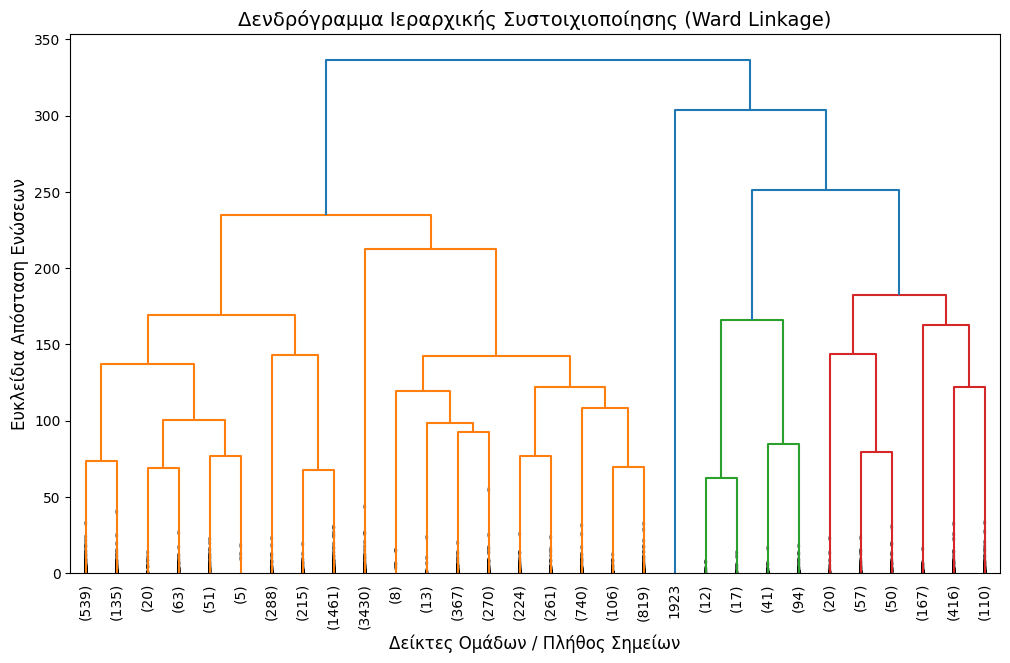

In [23]:
# ΚΕΛΙ 15

# Υπολογισμός του πίνακα ενώσεων (linkage matrix) χρησιμοποιώντας τη μέθοδο Ward
print("Υπολογισμός ιεραρχικών ενώσεων για το δενδρόγραμμα...")
Z = linkage(X_pca, method='ward')

# Σχεδίαση του Δενδρογράμματος
plt.figure(figsize=(12, 7))
dendrogram(
    Z,
    truncate_mode='lastp',  # Εμφανίζει μόνο τα τελευταία p clusters για να είναι ευανάγνωστο
    p=30,                   # Δείχνει τις τελευταίες 30 ενώσεις ομάδων
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Δενδρόγραμμα Ιεραρχικής Συστοιχιοποίησης (Ward Linkage)', fontsize=14)
plt.xlabel('Δείκτες Ομάδων / Πλήθος Σημείων', fontsize=12)
plt.ylabel('Ευκλείδια Απόσταση Ενώσεων', fontsize=12)
plt.grid(False)
plt.show()

In [24]:
# ΚΕΛΙ 16

# 1. Αρχικοποίηση και εκπαίδευση της Ιεραρχικής Συστοιχιοποίησης με βάση το δενδρόγραμμα (4 clusters)
optimal_hierarchical_clusters = 4
agg_clustering = AgglomerativeClustering(n_clusters=optimal_hierarchical_clusters, linkage='ward')
agg_preds = agg_clustering.fit_predict(X_pca)

# 2. Υπολογισμός μετρικών αξιολόγησης
print("Υπολογισμός μετρικών αξιολόγησης για την Ιεραρχική Συστοιχιοποίηση...")
agg_sh = silhouette_score(X_pca, agg_preds, random_state=42)
agg_dv = davies_bouldin_score(X_pca, agg_preds)

print("\n=== Αποτελέσματα Αξιολόγησης Ιεραρχικής Συστοιχιοποίησης (k=4) ===")
print(f"Δείκτης Silhouette (Hierarchical): {agg_sh:.4f}")
print(f"Δείκτης Davies-Bouldin (Hierarchical): {agg_dv:.4f}")

Υπολογισμός μετρικών αξιολόγησης για την Ιεραρχική Συστοιχιοποίηση...

=== Αποτελέσματα Αξιολόγησης Ιεραρχικής Συστοιχιοποίησης (k=4) ===
Δείκτης Silhouette (Hierarchical): 0.5236
Δείκτης Davies-Bouldin (Hierarchical): 0.9895


# Αξιολόγηση Αποτελεσμάτων Ιεραρχικής Συστοιχιοποίησης

Η Ιεραρχική Συστοιχιοποίηση (Agglomerative Clustering) εφαρμόστηκε με τη μέθοδο Ward, και ο βέλτιστος αριθμός ομάδων καθορίστηκε σε k = 4 έπειτα από τη γεωμετρική ανάλυση του Δενδρογράμματος.

## Ποσοτικά Αποτελέσματα:
* **Βέλτιστος Αριθμός Ομάδων (Τομή Δενδρογράμματος):** 4
* **Δείκτης Silhouette:** 0.5236
* **Δείκτης Davies-Bouldin:** 0.9895

## Ερμηνεία και Σχολιασμός:
* **Ανάλυση Δενδρογράμματος:** Η κοπή του δέντρου στο ύψος της ευκλείδιας απόστασης Y = 220 αποκάλυψε 4 κυρίαρχα κατακόρυφα κλαδιά (διακριτά χρωματικά), τα οποία υποδεικνύουν τις βασικές μακρο-δομές της δικτυακής κίνησης (π.χ. διαχωρισμός φυσιολογικής κυκλοφορίας από τις κύριες κατηγορίες επιθέσεων).
* **Ανάλυση Μετρικών:** Ο δείκτης Silhouette (0.5236) σημείωσε την υψηλότερη τιμή μεταξύ των αλγορίθμων, υποδηλώνοντας ότι το μοντέλο πέτυχε μια δομικά ισχυρή και συμπαγή ομαδοποίηση. Παράλληλα, ο δείκτης Davies-Bouldin υποχώρησε κάτω από το φράγμα της μονάδας (0.9895), γεγονός που επιβεβαιώνει μαθηματικά ότι οι 4 παραχθείσες ομάδες παρουσιάζουν εξαιρετικά υψηλό βαθμό γεωμετρικού διαχωρισμού και ελάχιστη μεταξύ τους επικάλυψη.

In [25]:
# ΚΕΛΙ 17 - ΤΕΛΙΚΟ KMEANS ME k=5

# 1. Εκτέλεση KMeans με το βέλτιστο k=5
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_sample)

# 2. Μετατροπή labels πίσω σε κανονικά ονόματα
try:
    real_names_sampled = label_encoder.inverse_transform(y_sample)
except NameError:
    try:
        real_names_sampled = le.inverse_transform(y_sample)
    except NameError:
        real_names_sampled = y_sample

# 3. Καθαρισμός ονομάτων Web Attack

cleaned_names = []

for name in real_names_sampled:
    if isinstance(name, str):
        if "Web Attack" in name:
            if "Brute Force" in name:
                cleaned_name = "Web Attack - Brute Force"
            elif "XSS" in name:
                cleaned_name = "Web Attack - XSS"
            elif "Sql Injection" in name:
                cleaned_name = "Web Attack - Sql Injection"
            else:
                cleaned_name = name
        else:
            cleaned_name = name
    else:
        cleaned_name = str(name)
    cleaned_names.append(cleaned_name)

# 4. Δημιουργία DataFrame validation
df_validation = pd.DataFrame({
    'Real_Label': cleaned_names,
    'KMeans_Cluster': clusters
})

# 5. Crosstab
crosstab = pd.crosstab(
    df_validation['Real_Label'],
    df_validation['KMeans_Cluster']
)

# 6. Εμφάνιση
print("=== ΠΙΝΑΚΑΣ ΔΙΑΣΤΑΥΡΩΣΗΣ: ΠΡΑΓΜΑΤΙΚΑ LABELS vs CLUSTERS (k=5) ===")

display(crosstab)

=== ΠΙΝΑΚΑΣ ΔΙΑΣΤΑΥΡΩΣΗΣ: ΠΡΑΓΜΑΤΙΚΑ LABELS vs CLUSTERS (k=5) ===


KMeans_Cluster,0,1,2,3,4
Real_Label,,,,,
BENIGN,5936,122,1,2032,220
Bot,5,0,0,3,0
DDoS,177,0,0,231,100
DoS GoldenEye,6,9,0,26,0
DoS Hulk,73,0,0,52,561
DoS Slowhttptest,3,0,0,12,6
DoS slowloris,3,7,0,5,6
FTP-Patator,5,0,0,18,0
PortScan,180,0,0,180,0


# Ερμηνεία Αποτελεσμάτων K-Means Clustering (k=5)

Βάσει του πίνακα διασταύρωσης, ο K-Means με 5 clusters κατάφερε να δημιουργήσει γενικευμένες ομάδες δικτυακής συμπεριφοράς, με το `BENIGN` traffic να κυριαρχεί κυρίως στο Cluster 0 (5936 εγγραφές) και στο Cluster 3 (2032 εγγραφές). Αυτό δείχνει ότι η φυσιολογική κίνηση δεν αποτελεί ενιαία ομάδα αλλά διαχωρίζεται σε πολλαπλά υπο-μοτίβα.

Οι περισσότερες επιθέσεις δεν σχηματίζουν καθαρά διακριτά clusters, αλλά κατανέμονται σε ομάδες μαζί με `BENIGN`, γεγονός που οφείλεται στην έντονη ανισορροπία του dataset και στην επικάλυψη χαρακτηριστικών μεταξύ κανονικής και κακόβουλης κίνησης.

Εξαίρεση αποτελεί το `DoS Hulk`, το οποίο συγκεντρώνεται κυρίως στο Cluster 4 (561 εγγραφές), υποδεικνύοντας ότι παρουσιάζει πιο συνεκτικό και αναγνωρίσιμο μοτίβο συμπεριφοράς σε σχέση με άλλες επιθέσεις.

Αντίστοιχα, το `DDoS` εμφανίζεται κυρίως σε περισσότερα clusters (0, 3 και 4), δείχνοντας ότι τα χαρακτηριστικά του επικαλύπτονται με benign traffic και δεν σχηματίζουν πλήρως διακριτή ομάδα.

Συνολικά, ο K-Means επιτυγχάνει μερικό διαχωρισμό των βασικών τύπων δικτυακής κίνησης, αλλά επηρεάζεται σημαντικά από την ανισορροπία των κλάσεων και την υψηλή ομοιότητα μεταξύ benign και attack patterns.


In [26]:
# ΚΕΛΙ 18 - ΠΙΝΑΚΑΣ ΔΙΑΣΤΑΥΡΩΣΗΣ ΓΙΑ DBSCAN

# 1. Μετατροπή labels πίσω σε κανονικά ονόματα

try:
    real_names_sampled = label_encoder.inverse_transform(y_sample)
except NameError:
    try:
        real_names_sampled = le.inverse_transform(y_sample) 
    except NameError:
        real_names_sampled = y_sample

# 2. Καθαρισμός ονομάτων Web Attack
cleaned_names = []

for name in real_names_sampled:
    if isinstance(name, str):
        if "Web Attack" in name:
            if "Brute Force" in name:
                cleaned_name = "Web Attack - Brute Force"
            elif "XSS" in name:
                cleaned_name = "Web Attack - XSS"
            elif "Sql Injection" in name:
                cleaned_name = "Web Attack - Sql Injection"
            else:
                cleaned_name = name
        else:
            cleaned_name = name
    else:
        cleaned_name = str(name)
    cleaned_names.append(cleaned_name)

# 3. Δημιουργία DataFrame validation
df_validation_dbscan = pd.DataFrame({
    'Real_Label': cleaned_names,
    'DBSCAN_Cluster': dbscan_preds
})

# 4. Crosstab
crosstab_dbscan = pd.crosstab(
    df_validation_dbscan['Real_Label'],
    df_validation_dbscan['DBSCAN_Cluster']
)

# 5. Εμφάνιση αποτελεσμάτων
print("=== ΠΙΝΑΚΑΣ ΔΙΑΣΤΑΥΡΩΣΗΣ: ΠΡΑΓΜΑΤΙΚΑ LABELS vs DBSCAN CLUSTERS ===")

display(crosstab_dbscan)

# 6. Επιπλέον πληροφορία για noise points
if -1 in dbscan_preds:
    
    noise_points = (dbscan_preds == -1).sum()
    total_points = len(dbscan_preds)
    noise_percentage = (noise_points / total_points) * 100

    print(f"\nNoise Points (-1): {noise_points}")
    print(f"Ποσοστό Noise: {noise_percentage:.2f}%")

=== ΠΙΝΑΚΑΣ ΔΙΑΣΤΑΥΡΩΣΗΣ: ΠΡΑΓΜΑΤΙΚΑ LABELS vs DBSCAN CLUSTERS ===


DBSCAN_Cluster,-1,0,1,2,3,4,5,6,7,8,...,56,57,58,59,60,61,62,63,64,65
Real_Label,,,,,,,,,,,,,,,,,,,,,
BENIGN,2018,3202,178,37,96,231,382,0,159,143,...,14,0,30,14,11,11,10,10,14,10
Bot,1,0,0,0,0,0,2,0,0,0,...,0,0,3,0,0,0,0,0,0,0
DDoS,132,0,0,0,0,177,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
DoS GoldenEye,41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DoS Hulk,182,0,0,0,0,36,0,216,0,0,...,0,12,0,0,0,1,0,0,0,4
DoS Slowhttptest,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DoS slowloris,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FTP-Patator,0,0,0,0,18,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PortScan,28,0,0,0,167,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Noise Points (-1): 2443
Ποσοστό Noise: 24.43%


# Ερμηνεία Αποτελεσμάτων DBSCAN

Βάσει του πίνακα διασταύρωσης, ο DBSCAN παρήγαγε μεγάλο αριθμό clusters, μαζί με σημαντική ποσότητα σημείων που χαρακτηρίστηκαν ως noise (`-1`). Συγκεκριμένα, μεγάλο μέρος του `BENIGN` traffic και των επιθέσεων κατανέμεται τόσο σε πολλαπλά μικρά clusters όσο και στο noise, γεγονός που δείχνει έντονη κατακερματισμένη δομή των δεδομένων.

Το cluster `-1` (noise) περιλαμβάνει σημαντικό αριθμό εγγραφών από όλες σχεδόν τις κατηγορίες, γεγονός που υποδεικνύει ότι πολλές ροές δεν ανήκουν σε σαφώς πυκνές περιοχές του feature space. Αυτό είναι αναμενόμενο σε δεδομένα όπως το CICIDS2017, όπου πολλές επιθέσεις εμφανίζουν σπάνια ή ανομοιογενή μοτίβα συμπεριφοράς.

Το `BENIGN` traffic κυριαρχεί και διασπείρεται σε πολλά διαφορετικά clusters, κάτι που υποδηλώνει ότι η φυσιολογική δικτυακή κίνηση δεν είναι ομοιογενής αλλά περιλαμβάνει πολλαπλές υπο-συμπεριφορές (π.χ. browsing, streaming, background traffic).

Ορισμένες επιθέσεις, όπως `DDoS` και `DoS Hulk`, εμφανίζουν μικρές συγκεντρώσεις σε συγκεκριμένα clusters, ωστόσο δεν σχηματίζουν πλήρως διακριτές ομάδες. Αντίθετα, πολλές σπάνιες κατηγορίες (π.χ. Web Attacks, Bot, FTP-Patator) είτε διασπείρονται είτε καταλήγουν κυρίως ως noise.

Συνολικά, ο DBSCAN αναδεικνύει τη δομή πυκνότητας των δεδομένων και εντοπίζει ανωμαλίες μέσω του noise, αλλά δεν επιτυγχάνει καθαρό διαχωρισμό όλων των κλάσεων λόγω της υψηλής ανισορροπίας και της έντονης επικάλυψης των χαρακτηριστικών.


In [ ]:
# ΚΕΛΙ 19
# ΚΕΛΙ - ΠΙΝΑΚΑΣ ΔΙΑΣΤΑΥΡΩΣΗΣ ΓΙΑ ΙΕΡΑΡΧΙΚΗ ΣΥΣΤΟΙΧΙΟΠΟΙΗΣΗ

# 1. Μετατροπή labels πίσω σε κανονικά ονόματα
try:
    real_names_sampled = label_encoder.inverse_transform(y_sample)
except NameError:
    try:
        real_names_sampled = le.inverse_transform(y_sample) 
    except NameError:
        real_names_sampled = y_sample

# 2. Καθαρισμός Web Attack labels
cleaned_names = []

for name in real_names_sampled:
    if isinstance(name, str):
        if "Web Attack" in name:
            if "Brute Force" in name:
                cleaned_name = "Web Attack - Brute Force"
            elif "XSS" in name:
                cleaned_name = "Web Attack - XSS"
            elif "Sql Injection" in name:
                cleaned_name = "Web Attack - Sql Injection"
            else:
                cleaned_name = name
        else:
            cleaned_name = name
    else:
        cleaned_name = str(name)
    cleaned_names.append(cleaned_name)


# 3. DataFrame για Hierarchical Clustering
df_validation_hier = pd.DataFrame({
    'Real_Label': cleaned_names,
    'Hierarchical_Cluster': agg_preds
})

# 4. Crosstab
crosstab_hier = pd.crosstab(
    df_validation_hier['Real_Label'],
    df_validation_hier['Hierarchical_Cluster']
)

# 5. Εκτύπωση
print("ΠΙΝΑΚΑΣ ΔΙΑΣΤΑΥΡΩΣΗΣ (k=4)")

display(crosstab_hier)

=== ΠΙΝΑΚΑΣ ΔΙΑΣΤΑΥΡΩΣΗΣ: ΠΡΑΓΜΑΤΙΚΑ LABELS vs HIERARCHICAL CLUSTERS (k=4) ===


Hierarchical_Cluster,0,1,2,3
Real_Label,,,,
BENIGN,7992,175,1,143
Bot,8,0,0,0
DDoS,424,84,0,0
DoS GoldenEye,28,0,0,13
DoS Hulk,125,561,0,0
DoS Slowhttptest,21,0,0,0
DoS slowloris,13,0,0,8
FTP-Patator,23,0,0,0
PortScan,360,0,0,0


# Ερμηνεία Αποτελεσμάτων  Hierarchical Clustering 

Βάσει του πίνακα διασταύρωσης, ο Hierarchical Clustering  κατάφερε να δημιουργήσει 4 clusters, με σαφή κυριαρχία του `BENIGN` traffic κυρίως στο Cluster 0 (7992 εγγραφές), ενώ μικρότερες ποσότητες κατανέμονται στα υπόλοιπα clusters. Αυτό δείχνει ότι η φυσιολογική κίνηση αποτελεί τον κύριο παράγοντα διαμόρφωσης της δομής των clusters.

Οι περισσότερες κατηγορίες επιθέσεων δεν διαχωρίζονται καθαρά, αλλά ενσωματώνονται σε clusters μαζί με `BENIGN`, γεγονός που οφείλεται στην έντονη ανισορροπία του dataset και στην επικάλυψη χαρακτηριστικών μεταξύ benign και malicious traffic.

Εξαίρεση αποτελεί το `DoS Hulk`, το οποίο εμφανίζει πιο εμφανή συγκέντρωση κυρίως στο Cluster 1 (561 εγγραφές), υποδεικνύοντας ότι έχει πιο διακριτό μοτίβο συμπεριφοράς σε σχέση με άλλες επιθέσεις.

Αντίθετα, κατηγορίες όπως `PortScan` και `DDoS` παραμένουν διάσπαρτες ή εν μέρει ενσωματωμένες στο BENIGN cluster, κάτι που δείχνει περιορισμένη ικανότητα πλήρους διαχωρισμού.

Συνολικά, η μέθοδος παράγει γενικευμένες ομάδες συμπεριφοράς, με μερική μόνο απομόνωση συγκεκριμένων επιθέσεων, κυρίως αυτών με πιο έντονα και επαναλαμβανόμενα μοτίβα δικτυακής κίνησης.
